# Airline Passenger Satisfaction Analysis

## Objective
The goal of this project is to analyze airline passenger reviews to:

1. Predict whether a passenger will recommend an airline (classification problem)
2. Identify key factors influencing passenger satisfaction
3. Extract common complaint and praise themes from textual reviews

## Business Value
- Help airlines improve customer experience
- Identify major pain points (e.g., delays, service quality)
- Support decision-making using data-driven insights

In [30]:

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import figure

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from fancyimpute import IterativeImputer
from sklearn.experimental import enable_iterative_imputer

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


from sklearn.feature_extraction.text import TfidfVectorizer

In [31]:
df = pd.read_csv(r"C:\Users\User\PyCharmMiscProject\Datasets\Airline Review (RAW).csv")

# Quick check
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23171 entries, 0 to 23170
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              23171 non-null  int64  
 1   Airline Name            23171 non-null  object 
 2   Overall_Rating          23171 non-null  object 
 3   Review_Title            23171 non-null  object 
 4   Review Date             23171 non-null  object 
 5   Verified                23171 non-null  bool   
 6   Review                  23171 non-null  object 
 7   Aircraft                7129 non-null   object 
 8   Type Of Traveller       19433 non-null  object 
 9   Seat Type               22075 non-null  object 
 10  Route                   19343 non-null  object 
 11  Date Flown              19417 non-null  object 
 12  Seat Comfort            19016 non-null  float64
 13  Cabin Staff Service     18911 non-null  float64
 14  Food & Beverages        14500 non-null

,Unnamed: 0,Seat Comfort,Cabin Staff Service,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money
count,23171.00000,19016.000000,18911.000000,14500.000000,18378.000000,10829.000000,5920.000000,22105.000000
mean,11585.00000,2.618374,2.871609,2.553586,2.353738,2.179056,1.780405,2.451165
std,6689.03588,1.464840,1.604631,1.526314,1.595747,1.488839,1.318800,1.594155
min,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,5792.50000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,11585.00000,3.000000,3.000000,2.000000,1.000000,2.000000,1.000000,2.000000
75%,17377.50000,4.000000,4.000000,4.000000,4.000000,3.000000,2.000000,4.000000
max,23170.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [32]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [33]:
# Convert rating to numeric
df['Overall_Rating'] = pd.to_numeric(df['Overall_Rating'], errors='coerce')


In [34]:
# Convert Recommended to binary
df['Recommended'] = df['Recommended'].map({'yes': 1, 'no': 0})

In [35]:
# Drop rows where target is missing
df = df.dropna(subset=['Recommended'])

In [36]:
print("Shape:", df.shape)

Shape: (23171, 19)


In [37]:
print("\nMissing Values:")
df.isnull().sum()


Missing Values:


Airline Name                  0
Overall_Rating              842
Review_Title                  0
Review Date                   0
Verified                      0
Review                        0
Aircraft                  16042
Type Of Traveller          3738
Seat Type                  1096
Route                      3828
Date Flown                 3754
Seat Comfort               4155
Cabin Staff Service        4260
Food & Beverages           8671
Ground Service             4793
Inflight Entertainment    12342
Wifi & Connectivity       17251
Value For Money            1066
Recommended                   0
dtype: int64

In [38]:
print("\nTarget Distribution:")
df['Recommended'].value_counts()


Target Distribution:


Recommended
0    15364
1     7807
Name: count, dtype: int64

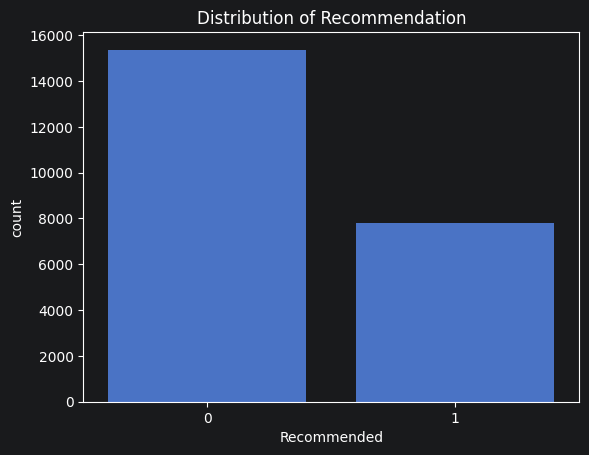

In [39]:
sns.countplot(x='Recommended', data=df)
plt.title("Distribution of Recommendation")
plt.show()

### Distribution of Ratings

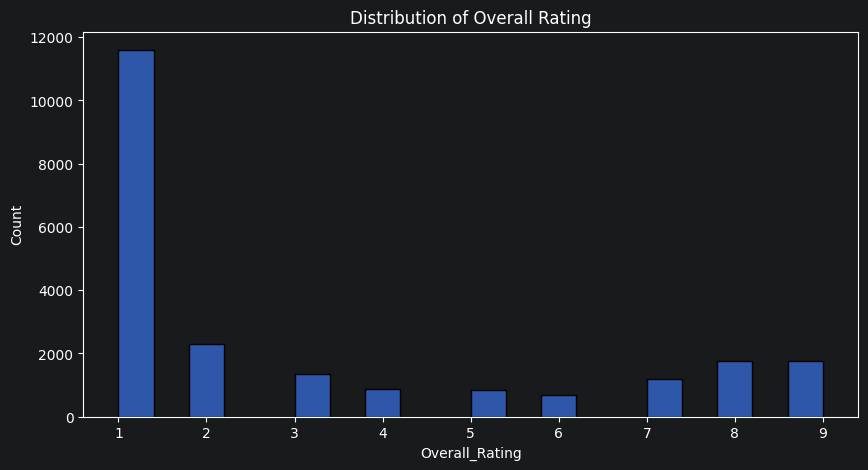

In [40]:
plt.figure(figsize = (10,5))
sns.histplot(df['Overall_Rating'].round(), bins=20)
plt.title("Distribution of Overall Rating")
plt.show()

### Distribution of Ratings value count

In [41]:
df['Overall_Rating'].round().value_counts()

Overall_Rating
1.0    11595
2.0     2296
9.0     1768
8.0     1757
3.0     1356
7.0     1193
4.0      859
5.0      830
6.0      675
Name: count, dtype: int64

### Rating vs Recommendation

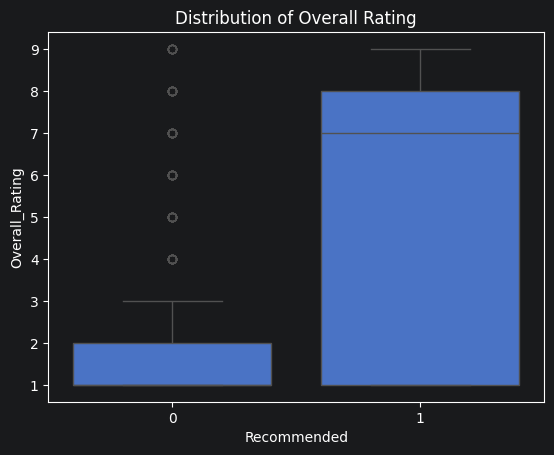

In [42]:
sns.boxplot(x="Recommended", y="Overall_Rating", data=df)
plt.title("Distribution of Overall Rating")
plt.show()

### Airline-wise Satisfaction

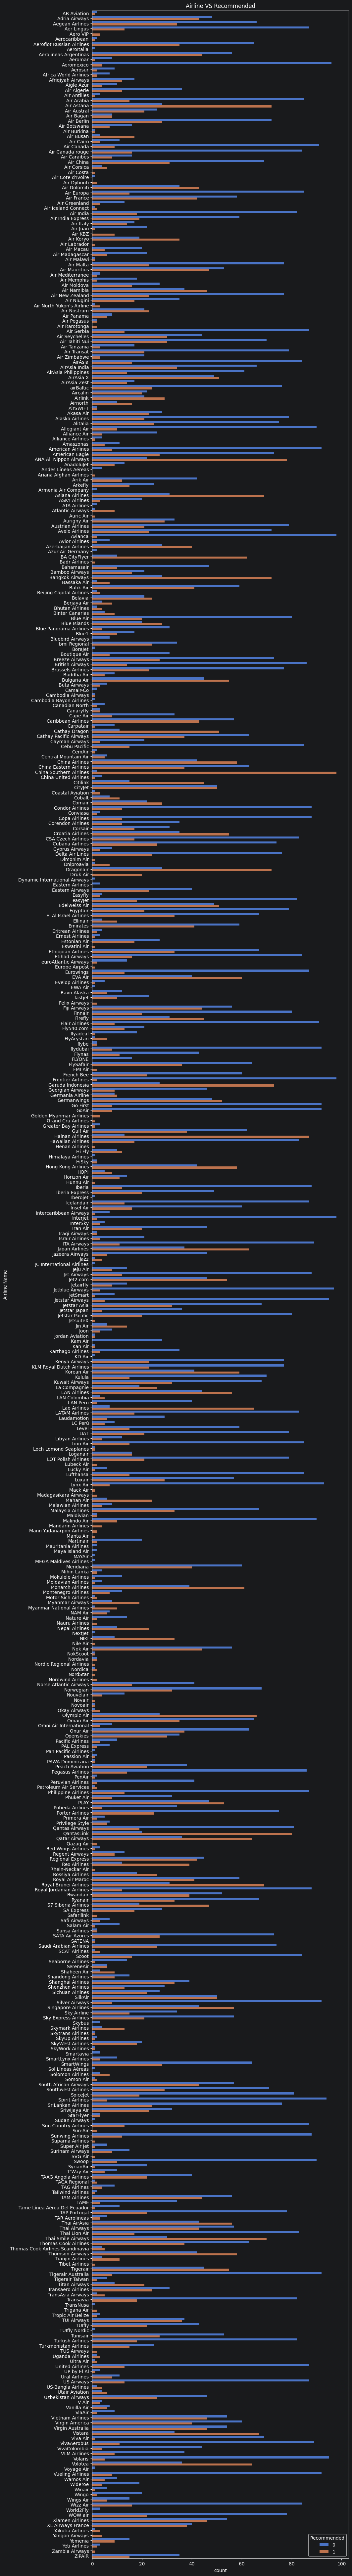

In [43]:
plt.figure(figsize = (10,100))
sns.countplot(y='Airline Name',hue="Recommended", data=df)
plt.title("Airline VS Recommended")
plt.show()

### Cabin Class Impact

In [44]:
df.columns
df["Seat Type"]

0         Economy Class
1         Economy Class
2         Economy Class
3         Economy Class
4         Economy Class
              ...      
23166     Economy Class
23167     Economy Class
23168     Economy Class
23169    Business Class
23170     Economy Class
Name: Seat Type, Length: 23171, dtype: object

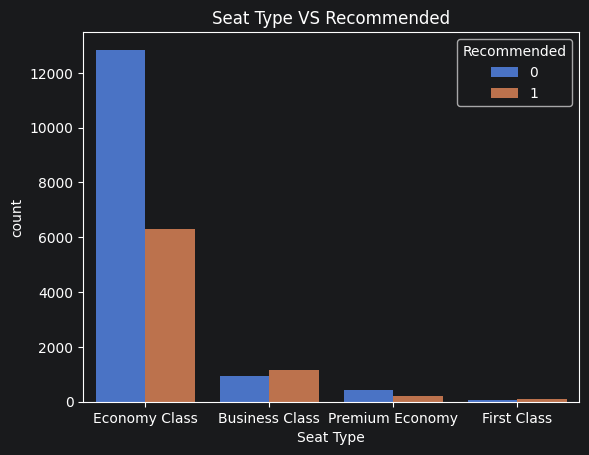

In [45]:
sns.countplot(x="Seat Type", hue="Recommended", data=df)
plt.title("Seat Type VS Recommended")
plt.show()

### Correlation Analysis

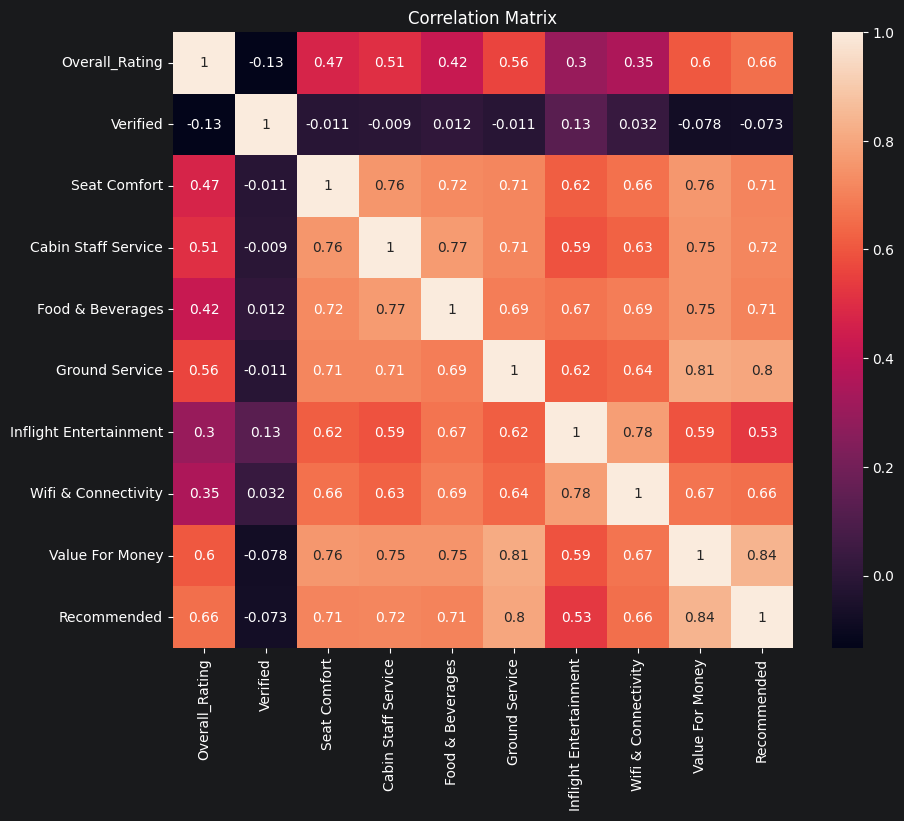

In [46]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [47]:
df['Service_Score'] = df[
    ['Seat Comfort', 'Cabin Staff Service', 'Food & Beverages',
     'Ground Service', 'Value For Money']
].mean(axis=1)#“Overall Service Experience”

In [48]:
df.drop(columns=['Verified'], inplace=True)#Useless Feature Detected

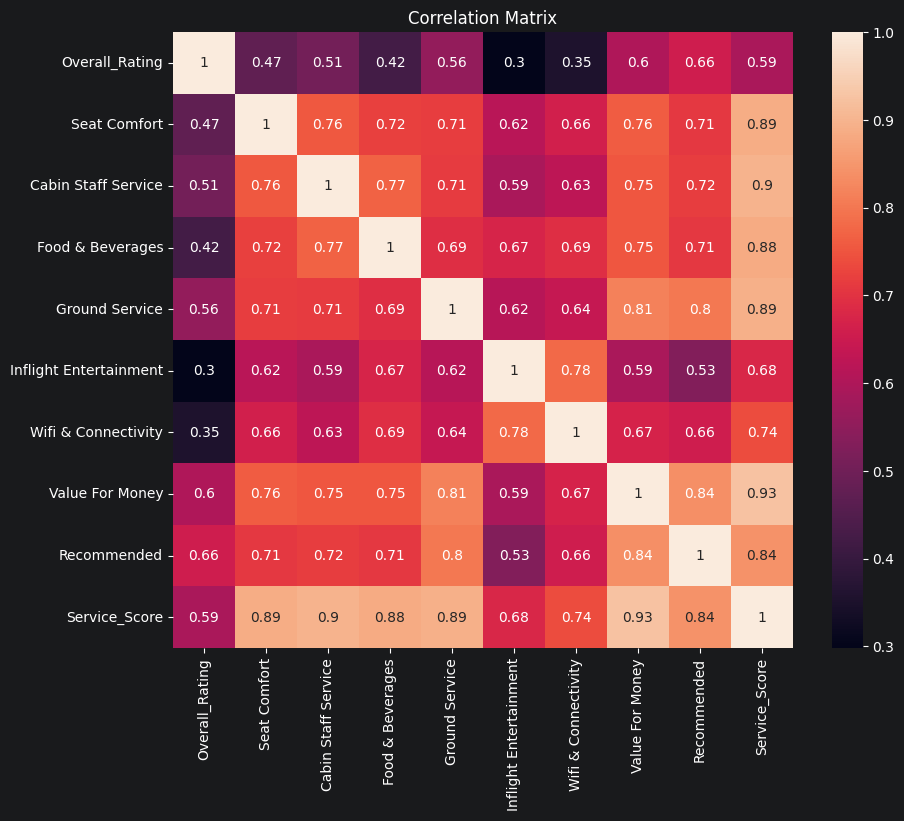

In [49]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [50]:
# Identify numeric columns

num_col = df.select_dtypes(include=['int64', 'float64']).columns
num_col

Index(['Overall_Rating', 'Seat Comfort', 'Cabin Staff Service',
       'Food & Beverages', 'Ground Service', 'Inflight Entertainment',
       'Wifi & Connectivity', 'Value For Money', 'Recommended',
       'Service_Score'],
      dtype='object')

In [51]:
# Identify Categorical columns

cat_col = df.select_dtypes(include=['object', 'category']).columns
cat_col

Index(['Airline Name', 'Review_Title', 'Review Date', 'Review', 'Aircraft',
       'Type Of Traveller', 'Seat Type', 'Route', 'Date Flown'],
      dtype='object')

### Data Imputation

In [52]:
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_col] = cat_imputer.fit_transform(df[cat_col])

mice_imputer = IterativeImputer(random_state=42, max_iter=100)
df[num_col] = mice_imputer.fit_transform(df[num_col])


In [53]:
y = df["Recommended"] #Target

X = df.drop(columns=['Recommended'])#Features

In [60]:
print(X.dtypes)

Airline Name               object
Overall_Rating            float64
Review_Title               object
Review Date                object
Review                     object
Aircraft                   object
Type Of Traveller          object
Seat Type                  object
Route                      object
Date Flown                 object
Seat Comfort              float64
Cabin Staff Service       float64
Food & Beverages          float64
Ground Service            float64
Inflight Entertainment    float64
Wifi & Connectivity       float64
Value For Money           float64
Service_Score             float64
dtype: object


In [55]:
X.isna().sum()

Airline Name              0
Overall_Rating            0
Review_Title              0
Review Date               0
Review                    0
Aircraft                  0
Type Of Traveller         0
Seat Type                 0
Route                     0
Date Flown                0
Seat Comfort              0
Cabin Staff Service       0
Food & Beverages          0
Ground Service            0
Inflight Entertainment    0
Wifi & Connectivity       0
Value For Money           0
Service_Score             0
dtype: int64